# Rule-based Approaches for EBM-NLP Extraction

In [1]:
# load dataset 
from datasets import load_dataset
import numpy as np
import pandas as pd
from pathlib import Path
import tarfile
import os

path_tofile = "/Users/zz/Desktop/ebm_nlp_2_00.tar.gz"
extract_directory = os.path.dirname(path_tofile)

if tarfile.is_tarfile(path_tofile):
    with tarfile.open(path_tofile) as f:
        f.extractall(path=extract_directory)

DATA_DIR = Path("/Users/zz/Desktop/ebm_nlp_2_00")
PHASES = ('starting_spans', 'hierarchical_labels')
ELEMENTS = ('participants', 'interventions', 'outcomes')
docs_dir = DATA_DIR / "documents"

In [2]:
#define classes and functions
import os, random
from glob import glob
from itertools import groupby, combinations
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, precision_recall_fscore_support

LABEL_DECODERS = { \
  PHASES[0] : { \
      'participants':  { 0: 'No Label', 1: 'p' },
      'interventions': { 0: 'No Label', 1: 'i' },
      'outcomes':      { 0: 'No Label', 1: 'o' }
    },
  PHASES[1]: { \
      'participants': { \
        0: 'No label',
        1: 'Age',
        2: 'Sex',
        3: 'Sample-size',
        4: 'Condition' },

      'interventions': { \
        0: 'No label',
        1: 'Surgical',
        2: 'Physical',
        3: 'Pharmacological',
        4: 'Educational',
        5: 'Psychological',
        6: 'Other',
        7: 'Control' },

      'outcomes': { \
        0: 'No label',
        1: 'Physical',
        2: 'Pain',
        3: 'Mortality',
        4: 'Adverse-effects',
        5: 'Mental',
        6: 'Other' }
    }
}

def rpad(inp, n, min_buf=0):
  s = str(inp)[:n - min_buf]
  return (s+' '*(n-len(s)))

def lpad(inp, n, min_buf=0):
  s = str(inp)[:n - min_buf]
  return (' '*(n-len(s))+s)

class Doc:
  def __init__(self, pmid, phase, element):
    with open(os.path.join(DATA_DIR, 'documents', '%s.txt' %pmid)) as fp:
      self.text = fp.read()
    with open(os.path.join(DATA_DIR, 'documents', '%s.tokens' %pmid)) as fp:
      self.tokens = fp.read().split('\n')
    self.pmid = pmid
    self.decoder = LABEL_DECODERS[phase][element]
    self.anns = {}

class Worker:
  def __init__(self, wid):
    self.wid = wid
    self.pmids = []

def get_pmids():
  doc_fnames = glob(os.path.join(DATA_DIR, 'documents', '*.text'))
  pmids = [os.path.basename(f).split('.')[0] for f in doc_fnames]
  return pmids

def read_anns(phase, element, ann_type = 'aggregated', model_phase = 'train'):
  workers = {}
  docs = {}

  fdir = os.path.join(DATA_DIR, 'annotations', ann_type, phase, element, model_phase)
  fnames = glob(os.path.join(fdir, '*.ann'))
  print('Found %d files in %s' %(len(fnames), fdir))

  for fname in fnames:
    labels = [int(i) for i in open(fname).read().strip().split('\n')]
    pmid, wid, f_ext = os.path.basename(fname).split('.')
    if pmid not in docs:
      docs[pmid] = Doc(pmid, phase, element)
    if wid not in workers:
      workers[wid] = Worker(wid)
    docs[pmid].anns[wid] = labels
    workers[wid].pmids.append(pmid)

  print('Loaded annotations for %d documents from %d worker%s' %(len(docs), len(workers), 's' if len(workers) != 1 else ''))
  return workers, docs

def print_token_labels(doc, width = 80): 
  t_str = '' 
  l_str = '' 
  for wid, labels in doc.anns.items():
    for t, l in zip(doc.tokens, labels):
      if l != 0:
        l_s = doc.decoder[l]
      else:
        l_s = ' '*len(t)
      slen = max(len(t), len(l_s))
      if len(t_str) + slen > width:
        if any([c != ' ' for c in l_str]):
          print(l_str)
        print(t_str)
        t_str = '' 
        l_str = '' 
      t_str += ' ' + rpad(t, slen)
      l_str += ' ' + rpad(l_s, slen)
    print(l_str)
    print(t_str)

def condense_labels(labels):
  groups = [(k, sum(1 for _ in g)) for k,g in groupby(labels)]
  spans = []
  i = 0
  for label, length in groups:
    if label != 0:
      spans.append((label, i, i+length))
    i += length
  return spans

def print_labeled_spans(doc):
  for wid, labels in doc.anns.items():
    label_spans = condense_labels(labels)
    print('Label spans for wid = %s' %wid)
    for label, token_i, token_f in label_spans:
      print('[%s]: %s ' %(doc.decoder[label], ' '.join(doc.tokens[token_i:token_f])))
    print()



### loading docs randomly to observe the regulations for designing rule-based approaches

In [3]:

import random

def get_span_sentence(doc, window = 10):
    result = []
    labels = list(doc.anns.values())[0]
    label_spans = condense_labels(labels)
    if not label_spans:
        return result
    for label, token_i, token_f in label_spans:
        l_span = " ".join(doc.tokens[max(0, token_i - window) : token_i])
        entity_span   = " ".join(doc.tokens[token_i : token_f])
        r_span= " ".join(doc.tokens[token_f : min(len(doc.tokens), token_f + window)])
        entitre_span = f"[{doc.decoder[label]}]: ... {l_span} 【 {entity_span} 】 {r_span} ..."
        result.append(
            {
                "pmid": doc.pmid,
                "span": entitre_span
            }
        )
    return result

def get_span_sentences(docs, element, num_samples = 15, window = 10, seed = 42):
    results = []
    random.seed(seed)
    num_actual_samples = min(num_samples, len(docs))
    random_pmids = random.sample(list(docs.keys()), num_actual_samples)
    for pmid in random_pmids:
        doc = docs[pmid]
        doc_spans = get_span_sentence(doc, window=window)
        results.extend(doc_spans)
    return results

_, p_docs = read_anns('starting_spans', 'participants', ann_type='aggregated', model_phase='train')
_, i_docs = read_anns('starting_spans', 'interventions', ann_type='aggregated', model_phase='train')
_, o_docs = read_anns('starting_spans', 'outcomes', ann_type='aggregated', model_phase='train')


p_raw_spans = get_span_sentences(p_docs, 'participants')
for i, result in enumerate(p_raw_spans):
    print(f"NO.{i+1}, ID: {result['pmid']}")
    print(f"{result['span']}")
    print()
print("-" * 150)

i_raw_spans = get_span_sentences(i_docs, 'interventions')
for i, result in enumerate(i_raw_spans):
    print(f"NO.{i+1}, ID: {result['pmid']}")
    print(f"{result['span']}")
    print()
print("-" * 150)

o_raw_spans = get_span_sentences(o_docs, 'outcomes')
for i, result in enumerate(o_raw_spans):
    print(f"NO.{i+1}, ID: {result['pmid']}")
    print(f"{result['span']}")
    print()



Found 4792 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/participants/train
Loaded annotations for 4792 documents from 1 worker
Found 4782 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/interventions/train
Loaded annotations for 4782 documents from 1 worker
Found 4670 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/outcomes/train
Loaded annotations for 4670 documents from 1 worker
NO.1, ID: 10889149
[p]: ... Atrophy and 【 intestinal metaplasia 】 one year after cure of H. pylori infection : a ...

NO.2, ID: 10889149
[p]: ... Atrophy and intestinal metaplasia one year after cure of 【 H. pylori infection : 】 a prospective , randomized study . BACKGROUND & AIMS Helicobacter ...

NO.3, ID: 10889149
[p]: ... course of premalignant histologic changes in the stomach . METHODS 【 Volunteers from the Yantai County in China underwent upper endoscopy with biopsy specimens obtained from the antrum and corpus

In [4]:
import re
def extract_features_p(text):
    all_matches = []
    p_sample = re.findall(r'\d+\s+\b(?:patients|men|women|males?|females?)\b', text, re.IGNORECASE) 
    all_matches.extend(p_sample)
    
    p_condition = re.findall(r'\b(?:patients|subjects|men|women|males?|females?)\s+(?:including|with|without)\s+[^\.,;]+',
                             text,
                             re.IGNORECASE)
                             
    all_matches.extend(p_condition)
        
    p_age = re.findall(r'\b(?:patients|men|women|male|female)\s*[≥≤><=]+\s*\d+\s*years?\b', 
                       text, 
                       re.IGNORECASE)
    all_matches.extend(p_age)
    return list(set(all_matches))


In [5]:
def extract_features_i(text):
 
    all_matches = []
    
    i_control = re.findall(r'\b(?:placebo|controlled)\b', text, re.IGNORECASE)
    all_matches.extend(i_control)
    
    i_drug = re.findall(r'\b\d+(?:\.\d+)?\s*(?:mg|ml)\b|\b\w+\s+(?:ointment|cream)\b', text, re.IGNORECASE)
    all_matches.extend(i_drug)
    
    i_surgical = re.findall(r'\b\w+\s+(?: therapy|resection|morcellation)\b', text, re.IGNORECASE)
    all_matches.extend(i_surgical)
    
    i_physical = re.findall(r'\b\w+\s+(?:ultrasound|devices?|monitoring)\b', text, re.IGNORECASE)
    all_matches.extend(i_physical)
    
    i_psycho = re.findall(r'\b\w+\s+(?:music|guided imagery|usual care)\b', text, re.IGNORECASE)
    all_matches.extend(i_psycho)
    return list(set(all_matches))

In [6]:
def extract_features_o(text):
    all_matches = []
    o_adverse = re.findall(r'\b(?:side effects?|adverse effects?|comlications?)\b', text, re.IGNORECASE)
    all_matches.extend(o_adverse)
    
    o_mental = re.findall(r'\b(?:cognitive|mental|agitation|distress|anxiety|depression)\b', text, re.IGNORECASE)
    all_matches.extend(o_mental)
    
    o_physical = re.findall(r'\b(?:\w+\s+)?(?:blood pressure|rate|blood flow|index|levels?|scores?)\b', text, re.IGNORECASE)
    all_matches.extend(o_physical)
    return list(set(all_matches))

In [7]:
import pandas as pd 

def get_pipeline(doc_ids, doc_tokens_list):
    final_results = []
    for pmid, tokens in zip(doc_ids, doc_tokens_list):
        full_text = " ".join(tokens).lower()
        p_results = extract_features_p(full_text)
        i_results = extract_features_i(full_text)
        o_results = extract_features_o(full_text)
        data = {
            "Document_ID": pmid,
            "Participants": " \n ".join(p_results) if len(p_results) > 0 else "Not Found",
            "Interventions": " \n ".join(i_results) if len(i_results) > 0 else "Not Found",
            "Outcomes": " \n ".join(o_results) if len(o_results) > 0 else "Not Found"
        } 
        final_results.append(data)    
    return final_results

In [8]:
_, p_test_docs = read_anns('starting_spans', 'participants', ann_type='aggregated', model_phase='test/gold')
_, i_test_docs = read_anns('starting_spans', 'interventions', ann_type='aggregated', model_phase='test/gold')
_, o_test_docs = read_anns('starting_spans', 'outcomes', ann_type='aggregated', model_phase='test/gold')

all_test_docs = {**p_test_docs, **i_test_docs, **o_test_docs}
all_test_ids = list(all_test_docs.keys())
all_test_tokens = [doc.tokens for doc in all_test_docs.values()]
final_resuts = get_pipeline(all_test_ids, all_test_tokens)
df_final = pd.DataFrame(final_resuts)
print(df_final.head(10))

Found 189 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/participants/test/gold
Loaded annotations for 189 documents from 1 worker
Found 188 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/interventions/test/gold
Loaded annotations for 188 documents from 1 worker
Found 190 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/outcomes/test/gold
Loaded annotations for 190 documents from 1 worker
  Document_ID                                       Participants  \
0     1459268                                          Not Found   
1    16505427  patients with cancer  \n patients with cancer-...   
2    25898782                                          Not Found   
3    10390665                                          Not Found   
4     9229602                                        69 patients   
5    10752495  patients with rheumatoid arthritis ( ra )  \n ...   
6    25931290                            

In [9]:
# def get_predictions_label(tokens, predict_spans):
#     predictions_label = [0] * len(tokens)
#     if not predict_spans or predict_spans == ["Not Found"]:
#         return predictions_label
#     tokens = [t.lower() for t in tokens]
#     for span in predict_spans:
#         predict_tokens = span.lower().split()
#         pre_tokens_len = len(predict_tokens)
#         if pre_tokens_len == 0: 
#             continue
#         for i in range(len(tokens) - pre_tokens_len + 1):
#             if tokens[i : i + pre_tokens_len] == predict_tokens:
#                 for j in range(i, i + pre_tokens_len):
#                     predictions_label[j] = 1
#     return predictions_label
    
def get_predictions_label(tokens, predict_spans):
    predictions_label = [0] * len(tokens)
    if not predict_spans or predict_spans == ["Not Found"]:
        return predictions_label 
    tokens_lower = [t.lower() for t in tokens]
    
    for span in predict_spans:
        predict_tokens = span.lower().split()
        if len(predict_tokens) == 0: 
            continue
            
        for p_token in predict_tokens:
            for i, t in enumerate(tokens_lower):
                if p_token in t or t in p_token: 
                    predictions_label[i] = 1                   
    return predictions_label

def evaluate_predictions(test_docs, extract_features_func, element):
    true_labels = []
    pred_labels = []
    for pmid, doc in test_docs.items():
        true_label = list(doc.anns.values())[0]
        true_labels.extend(true_label)
        full_text = " ".join(doc.tokens).lower()
        predicted_spans = extract_features_func(full_text)
        pred_label = get_predictions_label(doc.tokens, predicted_spans)
        pred_labels.extend(pred_label)    
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='binary', zero_division = 0)
    print(f"[{element}] Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f} \n")


_, p_test_docs = read_anns('starting_spans', 'participants', ann_type='aggregated', model_phase='test/gold')
_, i_test_docs = read_anns('starting_spans', 'interventions', ann_type='aggregated', model_phase='test/gold')
_, o_test_docs = read_anns('starting_spans', 'outcomes', ann_type='aggregated', model_phase='test/gold')



Found 189 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/participants/test/gold
Loaded annotations for 189 documents from 1 worker
Found 188 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/interventions/test/gold
Loaded annotations for 188 documents from 1 worker
Found 190 files in /Users/zz/Desktop/ebm_nlp_2_00/annotations/aggregated/starting_spans/outcomes/test/gold
Loaded annotations for 190 documents from 1 worker


### Score of the rule-based approach

In [10]:
evaluate_predictions(p_test_docs, extract_features_p, 'participants')
evaluate_predictions(i_test_docs, extract_features_i, 'interventions')
evaluate_predictions(o_test_docs, extract_features_o, 'outcomes')

[participants] Precision: 0.1797 | Recall: 0.3028 | F1-Score: 0.2255 

[interventions] Precision: 0.1009 | Recall: 0.0456 | F1-Score: 0.0628 

[outcomes] Precision: 0.3114 | Recall: 0.0890 | F1-Score: 0.1384 



# LLMs

In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("andresnowak/Qwen3-0.6B-instruction-finetuned")
model = AutoModelForCausalLM.from_pretrained("andresnowak/Qwen3-0.6B-instruction-finetuned")

In [12]:
def extract_features_p_llm(text):
    prompt = f"""
    Example 1: Text = 'arterial effects of chronic , asymmetric isosorbide dinitrate treatment in patients with ischemic heart disease .', participants = 'patients with ischemic heart disease'
    Example 2: Text = 'technology can provide an objective basis for the treatment of YEH patients with abundant phlegm-heat syndrome  using QRHT ', participants = 'YEH patients with abundant phlegm-heat syndrome'
    Example 3: Text = 'METHODS Patients ( men ≥ 45 years ; women ≥ 50 years ) with known or suspected coronary artery disease ( n = 124 )', participants = 'men ≥ 45 years'
    Example 4: Text = '{text}', participants = """
    
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=25)
        input_length = inputs['input_ids'].shape[1]
        pred = tokenizer.decode(output_ids[0][input_length:], skip_special_tokens=True).strip()

    return [pred] if pred else ["Not Found"]    

In [13]:
def extract_features_i_llm(text):
    prompt = f"""
    Example 1: Text = ' A double-blind , placebo-controlled , randomized study is described of an assessment', interventions = 'placebo-controlled'
    Example 2: Text = ' We tested the efficacy of single dose mebendazole 500 mg in the therapy of hookworm infection', interventions = 'mebendazole'
    Example 3: Text = 'OBJECTIVE To evaluate whether hysteroscopic morcellation or bipolar electrosurgical resection', interventions = 'bipolar electrosurgical resection'
    Example 4: Text = 'Group B received the same treatment but with pulsed ultrasound ', interventions = 'pulsed ultrasound'
    Example 5: Text = 'MATERIALS AND METHODS Patients were randomized to music , guided imagery , or usual care after completing a baseline questionnaire ', interventions = 'music , guided imagery , or usual care' 
    Example 6: Text = '{text}', interventions = """
    
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=25)
        input_length = inputs['input_ids'].shape[1]
        pred = tokenizer.decode(output_ids[0][input_length:], skip_special_tokens=True).strip()

    return [pred] if pred else ["Not Found"] 

In [14]:
def extract_features_o_llm(text):
    prompt = f"""
    Example 1: Text = 'RESULTS No side effects were observed', outcomes = 'side effects'
    Example 2: Text = 'analgesia may reduce the duration of hypoxemia and the associated distress and , therefore , may improve the long-term results', outcomes = 'distress'
    Example 3: Text = 'the recurrence rate of tumors in 308 patients after a follow-up period of twelve months', outcomes = 'the recurrence rate of tumors'
    Example 3: Text = '{text}', outcomes = """
    
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=25)
        input_length = inputs['input_ids'].shape[1]
        pred = tokenizer.decode(output_ids[0][input_length:], skip_special_tokens=True).strip()

    return [pred] if pred else ["Not Found"]    

### score of the LLM

In [15]:
evaluate_predictions(p_test_docs, extract_features_p_llm, 'participants')
evaluate_predictions(i_test_docs, extract_features_i_llm, 'interventions')
evaluate_predictions(o_test_docs, extract_features_o_llm, 'outcomes')

[participants] Precision: 0.1425 | Recall: 0.4836 | F1-Score: 0.2201 

[interventions] Precision: 0.1427 | Recall: 0.6173 | F1-Score: 0.2318 

[outcomes] Precision: 0.1647 | Recall: 0.3504 | F1-Score: 0.2241 



### Locked evaluation set + clean evaluator

Two issues with the original evaluation in this notebook:

1. `get_predictions_label` used substring matching (`p_token in t or t in p_token`),
   which means "patient" matches "outpatient" — recall numbers were inflated.
2. `evaluate_predictions` only printed; nothing was stored, so we cannot
   build a comparison table.

We fix both by (a) using exact normalised-token equality and (b) returning
metrics. We also align this notebook to the same locked test set used in
notebooks 03/04/05/06 so the final comparison is honest.


In [16]:
# add project root to path so we can import shared helpers
import sys
PROJECT_ROOT = os.path.abspath(os.path.dirname(os.path.dirname(os.getcwd()))) if os.path.basename(os.getcwd()) != 'src' else '..'
for candidate in [PROJECT_ROOT, '..', '.', '/content']:
    if os.path.exists(os.path.join(candidate, 'src', 'data.py')):
        if candidate not in sys.path:
            sys.path.insert(0, candidate)
        break

from src.data import (
    ensure_dataset, FIELDS, build_locked_eval_ids, load_eval_doc_ids,
    get_abstract_text, get_gold_spans, load_tokens, load_bio_labels,
)
from src.eval import (
    text_to_token_set, token_overlap_f1, coverage,
    run_queries, save_predictions,
)

ensure_dataset()
EVAL_IDS = load_eval_doc_ids() 
if not EVAL_IDS:
    EVAL_IDS = build_locked_eval_ids(n=50)
print(f'Evaluating on {len(EVAL_IDS)} locked test docs.')


Extracting archive ...
Dataset ready at ebm_nlp_2_00
Evaluating on 50 locked test docs.


In [17]:
from collections import Counter

def gold_token_set(doc_id, field):
    """Token-overlap gold set for a doc/field, properly normalised."""
    spans = get_gold_spans(doc_id, field, split='test')
    text = ' '.join(spans)
    return text_to_token_set(text)

def gold_text(doc_id, field):
    """Gold extraction as a single string for downstream queries."""
    return ' | '.join(get_gold_spans(doc_id, field, split='test'))


def run_extractor(extractor_fn, doc_ids, field):
    """Run an extractor over the eval set and return predictions dict."""
    preds = {}
    for doc_id in doc_ids:
        text = get_abstract_text(doc_id)
        try:
            spans = extractor_fn(text)
        except Exception as e:
            spans = []
        preds[doc_id] = ' | '.join(spans) if spans else ''
    return preds


def score_extractor(preds_by_field, doc_ids):
    """Compute (P, R, F1, coverage) per field over a locked doc set."""
    rows = []
    for field in FIELDS:
        ps, rs, fs = [], [], []
        for doc_id in doc_ids:
            pred = preds_by_field.get(field, {}).get(doc_id, '')
            gold = gold_token_set(doc_id, field)
            pred_tok = text_to_token_set(pred)
            p, r, f = token_overlap_f1(gold, pred_tok)
            ps.append(p); rs.append(r); fs.append(f)
        cov = sum(1 for d in doc_ids if preds_by_field.get(field, {}).get(d, '').strip()) / max(1, len(doc_ids))
        rows.append({'field': field,
                     'precision': sum(ps)/len(ps),
                     'recall':    sum(rs)/len(rs),
                     'f1':        sum(fs)/len(fs),
                     'coverage':  cov})
    return pd.DataFrame(rows)


### Run rule-based extractor on the locked eval set


In [18]:
extractors_rule = {
    'participants':  extract_features_p,
    'interventions': extract_features_i,
    'outcomes':      extract_features_o,
}

preds_rule = {field: run_extractor(fn, EVAL_IDS, field) for field, fn in extractors_rule.items()}
score_rule = score_extractor(preds_rule, EVAL_IDS)
print('Rule-based extractor:')
print(score_rule.round(3).to_string(index=False))


Rule-based extractor:
        field  precision  recall    f1  coverage
 participants      0.313   0.299 0.262      0.54
interventions      0.126   0.079 0.083      0.62
     outcomes      0.344   0.066 0.106      0.50


### Variant 3: dictionary / gazetteer-based extractor

Brief asks for 2–3 alternatives along an axis. We add a third: an extractor
based on high-frequency *training-set* entity terms. This is the simplest
"data-driven" baseline — no regex, no LLM — and represents what someone with
no NLP background would build given access to gold annotations.

We extract n-grams (1- to 3-token) from the gold spans of the training set,
keep the most common per field, and at test time tag any abstract token
sequence that matches one of those n-grams.


In [19]:
from src.data import get_doc_ids

def collect_training_spans(field, max_docs=200):
    """Return list of gold span strings from the training split."""
    train_ids = get_doc_ids('train', field)[:max_docs]
    spans = []
    for doc_id in train_ids:
        spans.extend(get_gold_spans(doc_id, field, split='train'))
    return spans


def build_gazetteer(field, top_k=200, max_docs=300):
    spans = collect_training_spans(field, max_docs=max_docs)
    cnt = Counter([s.lower().strip() for s in spans if 1 <= len(s.split()) <= 5])
    return [term for term, _ in cnt.most_common(top_k)]


GAZETTEER = {f: build_gazetteer(f) for f in FIELDS}
for f, terms in GAZETTEER.items():
    print(f'{f:14s} top 10 terms: {terms[:10]}')


participants   top 10 terms: ['children', 'women', 'autism', 'men', 'asthma', '10', 'substance-abusing suicidal', 'forty-five', '70', '12']
interventions  top 10 terms: ['placebo', 'placebo-controlled', 'secretin', 'enalapril', 'sertraline', 'fluoxetine', 'roxithromycin', 'clarithromycin', 'fentanyl', 'g-csf']
outcomes       top 10 terms: ['blood pressure', 'efficacy', 'efficacy and safety', 'pain', 'mortality', 'effective', 'heart rate', 'survival', 'hospital stay', 'allelic loss']


In [20]:
def make_gazetteer_extractor(terms):
    terms_sorted = sorted(set(terms), key=lambda x: -len(x))
    if not terms_sorted:
        return lambda text: []
    escaped = [re.escape(t) for t in terms_sorted if t]
    pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b', re.IGNORECASE)
    def fn(text):
        if not text:
            return []
        matches = [m.group(0).lower() for m in pattern.finditer(text)]
        seen, out = set(), []
        for m in matches:
            if m not in seen:
                out.append(m); seen.add(m)
        return out
    return fn


extractors_gaz = {f: make_gazetteer_extractor(GAZETTEER[f]) for f in FIELDS}
preds_gaz = {f: run_extractor(extractors_gaz[f], EVAL_IDS, f) for f in FIELDS}
score_gaz = score_extractor(preds_gaz, EVAL_IDS)
print('Gazetteer extractor:')
print(score_gaz.round(3).to_string(index=False))


Gazetteer extractor:
        field  precision  recall    f1  coverage
 participants      0.285   0.117 0.153      0.94
interventions      0.317   0.208 0.203      0.86
     outcomes      0.572   0.172 0.238      0.94


### LLM extractor on the locked eval set

The Qwen finetuned model takes ~2-5 sec per document on CPU. Skip this cell
if already ran it once and saved predictions to disk.


In [21]:
RUN_LLM = True

if RUN_LLM:
    extractors_llm = {
        'participants':  extract_features_p_llm,
        'interventions': extract_features_i_llm,
        'outcomes':      extract_features_o_llm,
    }
    preds_llm = {field: run_extractor(fn, EVAL_IDS, field) for field, fn in extractors_llm.items()}
    score_llm = score_extractor(preds_llm, EVAL_IDS)
    print('LLM extractor (Qwen3-0.6B fine-tuned):')
    print(score_llm.round(3).to_string(index=False))
else:
    preds_llm, score_llm = None, None


LLM extractor (Qwen3-0.6B fine-tuned):
        field  precision  recall    f1  coverage
 participants      0.305   0.417 0.314       1.0
interventions      0.286   0.544 0.315       1.0
     outcomes      0.156   0.171 0.154       1.0


### Comparison table


In [22]:
def label_score(df, label):
    df = df.copy()
    df.insert(0, 'approach', label)
    return df

frames = [label_score(score_rule, 'rule_based'), label_score(score_gaz, 'gazetteer')]
if score_llm is not None:
    frames.append(label_score(score_llm, 'llm_qwen'))
comparison_02 = pd.concat(frames, ignore_index=True)
print(comparison_02.round(3).to_string(index=False))
comparison_02.to_csv('results_02.csv', index=False)


  approach         field  precision  recall    f1  coverage
rule_based  participants      0.313   0.299 0.262      0.54
rule_based interventions      0.126   0.079 0.083      0.62
rule_based      outcomes      0.344   0.066 0.106      0.50
 gazetteer  participants      0.285   0.117 0.153      0.94
 gazetteer interventions      0.317   0.208 0.203      0.86
 gazetteer      outcomes      0.572   0.172 0.238      0.94
  llm_qwen  participants      0.305   0.417 0.314      1.00
  llm_qwen interventions      0.286   0.544 0.315      1.00
  llm_qwen      outcomes      0.156   0.171 0.154      1.00


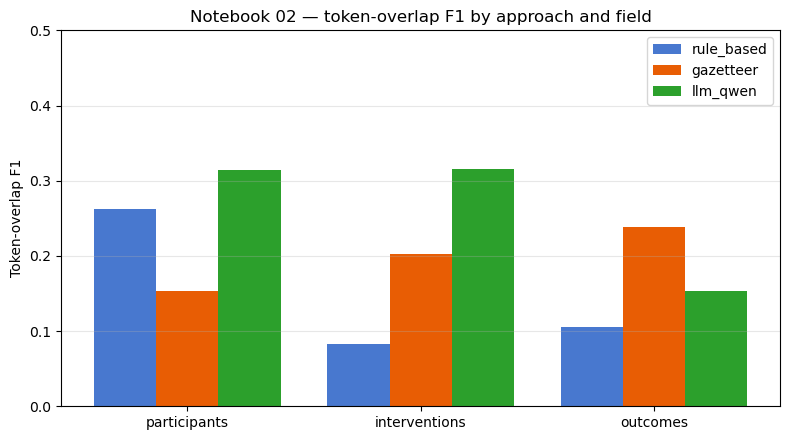

In [23]:
import matplotlib.pyplot as plt

approaches = comparison_02['approach'].unique().tolist()
fields = FIELDS
x = np.arange(len(fields))
w = 0.8 / len(approaches)
colours = ['#4878CF', '#E85D04', '#2CA02C']

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, ap in enumerate(approaches):
    sub = comparison_02[comparison_02['approach'] == ap].set_index('field').reindex(fields)
    ax.bar(x + i*w, sub['f1'].values, w, label=ap, color=colours[i % len(colours)])
ax.set_xticks(x + w*(len(approaches)-1)/2)
ax.set_xticklabels(fields)
ax.set_ylabel('Token-overlap F1')
ax.set_title('Notebook 02 — token-overlap F1 by approach and field')
ax.set_ylim(0, max(0.5, comparison_02['f1'].max() * 1.2))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results_02_f1.png', dpi=120, bbox_inches='tight')
plt.show()


### Downstream usability — keyword queries


In [24]:
def to_perdoc(preds_by_field):
    """reshape {field: {doc: text}} -> {doc: {field: text}}."""
    out = {}
    for field, dct in preds_by_field.items():
        for doc_id, text in dct.items():
            out.setdefault(doc_id, {})[field] = text
    return out

predictions_per_doc = {
    'rule_based': to_perdoc(preds_rule),
    'gazetteer':  to_perdoc(preds_gaz),
}
if preds_llm is not None:
    predictions_per_doc['llm_qwen'] = to_perdoc(preds_llm)

# build a gold reference 
gold_per_doc = {d: {f: gold_text(d, f) for f in FIELDS} for d in EVAL_IDS}

print(f'{"query":<32s} {"approach":<12s} {"matches":>8s} {"gold":>5s}')
print('-' * 60)
for query_result in run_queries(gold_per_doc):
    desc = query_result['query']
    gold_n = query_result['matches']
    for ap_name, preds in predictions_per_doc.items():
        ap_match = sum(1 for d in EVAL_IDS
                       if query_result['keyword'].lower() in preds.get(d, {}).get(query_result['field'], '').lower())
        print(f'{desc:<32s} {ap_name:<12s} {ap_match:>8d} {gold_n:>5d}')
    print()


query                            approach      matches  gold
------------------------------------------------------------
Trials with placebo              rule_based         12    11
Trials with placebo              gazetteer          12    11
Trials with placebo              llm_qwen            4    11

Trials mentioning patients       rule_based         25    33
Trials mentioning patients       gazetteer           1    33
Trials mentioning patients       llm_qwen           27    33

Trials measuring pain            rule_based          1     5
Trials measuring pain            gazetteer           5     5
Trials measuring pain            llm_qwen            2     5

Trials with rehabilitation       rule_based          0     0
Trials with rehabilitation       gazetteer           0     0
Trials with rehabilitation       llm_qwen            1     0



### Save predictions for the master comparison

Notebook 07 (and the report's master table) reads these JSON files.


In [25]:
save_predictions('rule_based', predictions_per_doc['rule_based'])
save_predictions('gazetteer',  predictions_per_doc['gazetteer'])
if 'llm_qwen' in predictions_per_doc:
    save_predictions('llm_qwen', predictions_per_doc['llm_qwen'])
print('Saved predictions to ./predictions/')


Saved predictions to ./predictions/


### Error analysis — what does the rule-based extractor miss?


In [26]:
# worst-performing examples per field for the rule-based extractor
def worst_docs(preds_by_field, eval_ids, field, n=3):
    rows = []
    for d in eval_ids:
        pred = preds_by_field.get(field, {}).get(d, '')
        gold = gold_token_set(d, field)
        pred_tok = text_to_token_set(pred)
        p, r, f = token_overlap_f1(gold, pred_tok)
        rows.append((d, f, gold, pred_tok))
    rows.sort(key=lambda x: x[1])
    return rows[:n]


for field in FIELDS:
    print('=' * 70)
    print(f'Worst rule-based extractions: {field}')
    print('=' * 70)
    for doc_id, f1, gold, pred in worst_docs(preds_rule, EVAL_IDS, field, n=2):
        print(f'  Doc {doc_id} | F1={f1:.2f}')
        print(f'    Gold: {sorted(list(gold))[:8]}')
        print(f'    Pred: {sorted(list(pred))[:8]}')
        # Show a slice of abstract for context
        print(f'    Abstract (first 200 chars): {get_abstract_text(doc_id)[:200]}')
        print()


Worst rule-based extractions: participants
  Doc 10390665 | F1=0.00
    Gold: ['4-10', '90', 'adenoidectomy', 'aged', 'anaesthesia', 'asa', 'children', 'for']
    Pred: []
    Abstract (first 200 chars): Anti-emetic efficacy of prophylactic granisetron compared with perphenazine for the prevention of post-operative vomiting in children . We have compared the efficacy of granisetron with perphenazine i

  Doc 10578479 | F1=0.00
    Gold: ['20', '36', 'non-oc', 'oc', 'premenopausal', 'used', 'users', 'women']
    Pred: []
    Abstract (first 200 chars): Effects of soy intake on sex hormone metabolism in premenopausal women . Studies suggest that phytoestrogens in soy products may impart hormonal effects that protect women against breast cancer . Limi

Worst rule-based extractions: interventions
  Doc 10070173 | F1=0.00
    Gold: ['aqua', 'budesonide', 'powder', 'spray', 'turbuhaler']
    Pred: ['256', '400', 'devices', 'mg', 'nasal']
    Abstract (first 200 chars): Comparison of budesoni